# ALS matrix factorization for rating prediction

Explicit-feedback matrix factorization of the **user × recipe** rating matrix, fitted by **alternating least squares** (ALS).

**Data** (`input_stage2/recipe_user_ratings.csv`)

- The target is `rating`. Only ratings of 1 or more count; rating 0 is a review without stars.
- If a user rated the same recipe more than once, only the latest rating is kept.
- Only users with at least 6 ratings are kept. Every row of the other users is discarded.
- **Split**, per user by date: the latest rating is **test**, the one before it is **valid**, and the rest (at least 4) are **train**.
  Valid picks the regularization strengths and the iteration to keep. Test is used only for the final report.

**Model and loss**

$$\hat r_{ui} = \mu + b_u + c_i + p_u^\top q_i$$

$\mu$ is the weighted train mean, $b_u$ and $c_i$ are the user and recipe biases, and $p_u, q_i \in \mathbb{R}^k$ are the latent factors.
Training minimizes a class-weighted squared error plus an **L2 penalty**:

$$L = \sum_{(u,i) \in \text{train}} w_{r_{ui}} \big(r_{ui} - \hat r_{ui}\big)^2 + \lambda \Big(\sum_u \lVert p_u \rVert^2 + \sum_i \lVert q_i \rVert^2\Big) + \lambda_b \Big(\sum_u b_u^2 + \sum_i c_i^2\Big)$$

**Class weights.** Most ratings are 5★, so an unweighted fit mostly learns to predict a high rating and rarely gets the low ones right.
A rating of $r$ stars gets the weight $w_r \propto \big(n / (5\, n_r)\big)^{\beta}$, scaled so that the mean train weight is 1. Here $n_r$ is the number of
train ratings equal to $r$, $n$ is the number of all train ratings, and $\beta$ = `WEIGHT_BALANCE`. $\beta = 0$ is unweighted. $\beta = 1$ is scikit-learn's
`"balanced"` (the reranker's `CLASS_WEIGHT`): every rating level carries the same total weight. Values in between balance partly.

**ALS.** With every recipe's $(q_i, c_i)$ fixed, $L$ splits into one weighted ridge regression per user, which has a closed-form solution:

$$\begin{bmatrix} p_u \\ b_u \end{bmatrix} = \big(Z_u^\top W_u Z_u + \Lambda\big)^{-1} Z_u^\top W_u \big(r_u - \mu - c_{I_u}\big), \qquad Z_u = \begin{bmatrix} q_i^\top & 1 \end{bmatrix}_{i \in I_u}, \qquad \Lambda = \operatorname{diag}(\lambda, \dots, \lambda, \lambda_b)$$

$I_u$ is the set of recipes user $u$ rated in train, $r_u$ holds those ratings, and the diagonal matrix $W_u$ holds their weights.
The recipe step is the same with users and recipes swapped. Each step minimizes $L$ exactly over the parameters it updates, so $L$ never increases.

**Why the penalty matters.** Without it, a recipe with a single train rating could fit that rating exactly.
With it, parameters backed by little rating weight stay close to 0: in the biases-only model, a recipe bias is the weighted mean residual of its
ratings times $W / (W + \lambda_b)$, where $W$ is their total weight ($W = n$ when unweighted).
A small $\lambda$ gives a low train error but a high valid error (overfitting). A very large $\lambda$ shrinks every factor to 0, which leaves the biases-only model.

**Metrics.** RMSE, MAE, and a **weighted RMSE**: the root of the mean of the per-rating MSEs on the split being scored, so each rating level 1–5
counts the same however rare it is. It does not depend on `WEIGHT_BALANCE`, so runs with different class weights stay comparable.
Per rating, precision, recall, and F1 treat each prediction, rounded to the nearest star, as a class.

**Tuning.** $\lambda_b$ is picked first on a **biases-only** model ($k = 0$), which is also the bias baseline.
Then $\lambda$ is picked for the $k$-factor model with that $\lambda_b$. Both choices, and early stopping, use the valid metric `SELECT_BY`
(weighted RMSE by default). A recipe with no train rating gets $q_i = 0$ and $c_i = 0$, so its prediction falls back to $\mu + b_u$.

In [10]:
# Run once if these packages are missing, then restart the notebook kernel.
# %pip install numpy pandas scipy scikit-learn matplotlib
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from IPython.display import display
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import precision_recall_fscore_support

In [11]:
RANDOM_STATE = 42
NOTEBOOK_DIR = next((p for p in (Path.cwd(), Path.cwd() / "DataMappingRecommendation")
                     if (p / "input_stage2/recipe_user_ratings.csv").is_file()), None)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Run from DataMappingRecommendation or its project root.")
DATA_PATH = NOTEBOOK_DIR / "input_stage2/recipe_user_ratings.csv"
ALS_DIR = NOTEBOOK_DIR / "model_artifacts/mf_als"

RATING_MIN, RATING_MAX = 1, 5  # Rows rated below RATING_MIN (0 = a review without stars) are dropped; predictions are clipped to this range.
MIN_USER_RATINGS = 6  # Users with fewer ratings are discarded, with all their rows.
WEIGHT_BALANCE = 1.0  # beta: class weight (n / (5 n_r)) ** beta. 0 = unweighted, 1 = "balanced" (each rating level weighs the same).
SELECT_BY = "weighted rmse"  # The valid metric that picks lambda_b, lambda, and the kept iteration: "weighted rmse" or "rmse".

FACTORS = 32  # k: the size of p_u and q_i.
L2_BIAS_GRID = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]  # lambda_b candidates, tried on the biases-only model.
L2_GRID = [1.0, 3.0, 10.0, 30.0, 100.0, 300.0]  # lambda candidates for the factors.
INIT_STD = 0.1  # q_i starts as N(0, INIT_STD^2); the first user step solves the user side from it.
MAX_ITERATIONS = 25  # One iteration is a user step followed by a recipe step.
EARLY_STOPPING_PATIENCE = 3  # Stop after this many iterations without a better valid SELECT_BY,
MIN_IMPROVEMENT = 1e-4  # where better means lower by more than this.
CHUNK_ELEMENTS = 2**22  # At most this many float64 values (32 MB) per array in a batch of normal equations.
print(f"Ratings: {DATA_PATH}\nArtifacts: {ALS_DIR}")

Ratings: /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/input_stage2/recipe_user_ratings.csv
Artifacts: /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/mf_als


## Data: ratings of 1–5, users with at least 6 ratings, split per user by date

In [12]:
source = pd.read_csv(DATA_PATH, usecols=["user_id", "recipe_id", "rating", "date"])
rated = source[source["rating"] >= RATING_MIN].assign(date=lambda frame: pd.to_datetime(frame["date"], format="mixed"))
# One rating per (user, recipe): the latest.
ratings = rated.sort_values("date", kind="stable").drop_duplicates(["user_id", "recipe_id"], keep="last")
kept = ratings[ratings["user_id"].map(ratings["user_id"].value_counts()) >= MIN_USER_RATINGS]
print(f"{len(source):,} rows: {len(source) - len(rated):,} rated below {RATING_MIN} dropped, "
      f"{len(rated) - len(ratings):,} repeated (user, recipe) pairs merged -> {len(ratings):,} ratings "
      f"from {ratings['user_id'].nunique():,} users")
print(f"Users with >= {MIN_USER_RATINGS} ratings: {kept['user_id'].nunique():,} kept, with {len(kept):,} ratings on "
      f"{kept['recipe_id'].nunique():,} recipes; {ratings['user_id'].nunique() - kept['user_id'].nunique():,} users "
      f"and their {len(ratings) - len(kept):,} ratings discarded")

# Per user, by date: the latest rating is test, the one before it valid, the rest train. Same-day ties keep file order.
kept = kept.sort_values(["user_id", "date"], kind="stable").reset_index(drop=True)
from_end = kept.groupby("user_id").cumcount(ascending=False).to_numpy()  # 0 = the user's latest rating
split = np.select([from_end == 0, from_end == 1], ["test", "valid"], "train")
splits = {name: kept[split == name].reset_index(drop=True) for name in ("train", "valid", "test")}

train_recipe_ids = set(splits["train"]["recipe_id"])
split_summary = pd.DataFrame({
    name: {"ratings": len(frame), "users": frame["user_id"].nunique(), "recipes": frame["recipe_id"].nunique(),
           "recipe not in train": (~frame["recipe_id"].isin(train_recipe_ids)).mean(),
           "mean rating": frame["rating"].mean(),
           **{f"share {r}★": frame["rating"].eq(r).mean() for r in range(RATING_MIN, RATING_MAX + 1)}}
    for name, frame in splits.items()}).T
display(split_summary.round(3))

1,132,367 rows: 60,847 rated below 1 dropped, 0 repeated (user, recipe) pairs merged -> 1,071,520 ratings from 196,098 users
Users with >= 6 ratings: 18,831 kept, with 829,411 ratings on 206,212 recipes; 177,267 users and their 242,109 ratings discarded


,ratings,users,recipes,recipe not in train,mean rating,share 1★,share 2★,share 3★,share 4★,share 5★
train,791749.0,18831.0,202600.0,0.000,4.688,0.005,0.010,0.038,0.186,0.761
valid,18831.0,18831.0,13196.0,0.094,4.689,0.013,0.016,0.036,0.140,0.796
test,18831.0,18831.0,13083.0,0.103,4.705,0.013,0.017,0.032,0.129,0.809


## Rating matrix

Users and recipes are indexed from **train** only. `R` is the train rating matrix (users × recipes, CSR), and its
transpose (recipes × users) drives the recipe step. A valid or test recipe that has no train rating gets index −1.

In [13]:
user_ids = np.sort(splits["train"]["user_id"].unique())
recipe_ids = np.sort(splits["train"]["recipe_id"].unique())
user_index, recipe_index = pd.Index(user_ids), pd.Index(recipe_ids)


def encode(frame):
    # (user index, recipe index, rating) arrays; a user or recipe that is not in train gets index -1.
    return (user_index.get_indexer(frame["user_id"]), recipe_index.get_indexer(frame["recipe_id"]),
            frame["rating"].to_numpy(np.float64))


encoded = {name: encode(frame) for name, frame in splits.items()}
train_users, train_recipes, train_values = encoded["train"]
R = sp.csr_matrix((train_values, (train_users, train_recipes)), shape=(len(user_ids), len(recipe_ids)))
per_user, per_recipe = np.diff(R.indptr), np.diff(R.tocsc().indptr)
print(f"R: {R.shape[0]:,} users x {R.shape[1]:,} recipes, {R.nnz:,} ratings (density {R.nnz / np.prod(R.shape):.3%})")
print(f"Train ratings per user: min {per_user.min()}, median {np.median(per_user):.0f}, max {per_user.max():,}; "
      f"per recipe: median {np.median(per_recipe):.0f}, max {per_recipe.max():,}, "
      f"{np.mean(per_recipe == 1):.0%} of recipes have one")

# Class weights w_r from the train counts n_r; rating_weight[r] is the weight of an r-star rating.
train_counts = np.bincount(train_values.astype(int), minlength=RATING_MAX + 1)
rating_weight = np.zeros(RATING_MAX + 1)
present = train_counts > 0
rating_weight[present] = (len(train_values) / ((RATING_MAX - RATING_MIN + 1) * train_counts[present])) ** WEIGHT_BALANCE
rating_weight /= rating_weight[train_values.astype(int)].mean()  # The mean train weight is 1.
print(f"Class weights (WEIGHT_BALANCE = {WEIGHT_BALANCE:g}): "
      + ", ".join(f"{r}★ {rating_weight[r]:.3f}" for r in range(RATING_MIN, RATING_MAX + 1))
      + f"; weighted train mean {np.average(train_values, weights=rating_weight[train_values.astype(int)]):.3f}")

R: 18,831 users x 202,600 recipes, 791,749 ratings (density 0.021%)
Train ratings per user: min 4, median 11, max 7,663; per recipe: median 2, max 915, 44% of recipes have one
Class weights (WEIGHT_BALANCE = 1): 1★ 40.252, 2★ 20.037, 3★ 5.273, 4★ 1.074, 5★ 0.263; weighted train mean 3.000


## ALS with L2 regularization and class weights

- `ridge_rows` is one half-step: a weighted ridge regression for every row of a sparse target matrix, meaning every user or every recipe.
  Rows with the same number of ratings $c$ are stacked into a `[rows, c, k + 1]` array, so one batched matmul builds their
  $Z^\top W Z$ and one `np.linalg.solve` call solves them.
- `fit_als` alternates the user and recipe steps. After each iteration it records the loss $L$ (and warns if it rises), and the
  RMSE and weighted RMSE on train and valid. It returns the iteration with the best valid `SELECT_BY`, and it stops after
  `EARLY_STOPPING_PATIENCE` iterations without an improvement.
- Every RMSE uses predictions clipped to [1, 5]; $L$ uses the unclipped model.

In [14]:
def ridge_rows(targets, weights, design, reg):
    """One ALS half-step: a weighted ridge regression for every row of the CSR matrix `targets`.

    With t_r the row's stored values, w_r their weights (`weights` is aligned with targets.data), and
    Z_r = design[the row's columns], row r gets
        x_r = argmin_x sum_j w_rj (t_rj - Z_rj x)^2 + sum_d reg_d * x_d^2 = (Z_r^T W_r Z_r + diag(reg))^-1 Z_r^T W_r t_r.
    """
    d = design.shape[1]
    solution = np.zeros((targets.shape[0], d))  # A row without ratings keeps x = 0.
    counts = np.diff(targets.indptr)
    for c in np.unique(counts[counts > 0]):
        same = np.flatnonzero(counts == c)
        step = max(1, CHUNK_ELEMENTS // ((c + d) * d))  # Rows per batch, to bound memory.
        for start in range(0, len(same), step):
            rows = same[start:start + step]
            at = targets.indptr[rows][:, None] + np.arange(c)  # [rows, c]: where each row's ratings are stored
            Z = design[targets.indices[at]]  # [rows, c, d]
            WZ = Z * weights[at][..., None]  # W_r Z_r
            gram = np.swapaxes(WZ, 1, 2) @ Z + np.diag(reg)  # Z^T W Z + diag(reg)
            rhs = np.einsum("rcd,rc->rd", WZ, targets.data[at])  # Z^T W t
            solution[rows] = np.linalg.solve(gram, rhs[..., None])[..., 0]
    return solution


def predict(model, users, recipes, clip=True):
    # mu + b_u + c_i + p_u . q_i. A user or recipe outside train (index -1) adds nothing.
    pred = np.full(len(users), model["mu"])
    known_user, known_recipe = users >= 0, recipes >= 0
    pred[known_user] += model["user_bias"][users[known_user]]
    pred[known_recipe] += model["item_bias"][recipes[known_recipe]]
    both = known_user & known_recipe
    pred[both] += np.einsum("nk,nk->n", model["user_factors"][users[both]], model["item_factors"][recipes[both]])
    return pred.clip(RATING_MIN, RATING_MAX) if clip else pred


def regression_metrics(y, pred):
    # "weighted rmse": the root of the mean of the per-rating MSEs, so every rating level in y weighs the same.
    error, level = pred - y, y.astype(int)
    count = np.bincount(level)
    level_mse = np.bincount(level, weights=error ** 2)[count > 0] / count[count > 0]
    return {"mse": float(np.mean(error ** 2)), "rmse": float(np.sqrt(np.mean(error ** 2))),
            "weighted rmse": float(np.sqrt(level_mse.mean())), "mae": float(np.mean(np.abs(error)))}


def als_loss(model, R, users, weight, l2, l2_bias):
    # L: class-weighted squared error on train plus the L2 penalties.
    error = R.data - predict(model, users, R.indices, clip=False)
    factors = (model["user_factors"] ** 2).sum() + (model["item_factors"] ** 2).sum()
    biases = (model["user_bias"] ** 2).sum() + (model["item_bias"] ** 2).sum()
    return float(error @ (weight * error) + l2 * factors + l2_bias * biases)


def fit_als(R, valid, factors, l2, l2_bias, name):
    n_users, n_recipes = R.shape
    Rt = R.T.tocsr()  # Recipes x users, for the recipe step.
    users = np.repeat(np.arange(n_users), np.diff(R.indptr))  # The user of each stored rating.
    weight, weight_t = rating_weight[R.data.astype(int)], rating_weight[Rt.data.astype(int)]  # w of each stored rating
    reg = np.r_[np.full(factors, l2), l2_bias]  # Penalty on [p_u, b_u] and on [q_i, c_i].
    mu = np.average(R.data, weights=weight)
    model = {"mu": mu, "user_factors": np.zeros((n_users, factors)), "user_bias": np.zeros(n_users),
             "item_factors": np.random.default_rng(RANDOM_STATE).normal(0, INIT_STD, (n_recipes, factors)),
             "item_bias": np.zeros(n_recipes)}
    history, best, best_model, stale, loss = [], np.inf, None, 0, np.inf
    for iteration in range(1, MAX_ITERATIONS + 1):
        started = time.time()
        # User step, recipes fixed: target r - mu - c_i, design [q_i, 1], unknowns [p_u, b_u].
        targets = sp.csr_matrix((R.data - mu - model["item_bias"][R.indices], R.indices, R.indptr), shape=R.shape)
        x = ridge_rows(targets, weight, np.c_[model["item_factors"], np.ones(n_recipes)], reg)
        model["user_factors"], model["user_bias"] = x[:, :factors], x[:, factors]
        # Recipe step, users fixed: target r - mu - b_u, design [p_u, 1], unknowns [q_i, c_i].
        targets = sp.csr_matrix((Rt.data - mu - model["user_bias"][Rt.indices], Rt.indices, Rt.indptr), shape=Rt.shape)
        y = ridge_rows(targets, weight_t, np.c_[model["user_factors"], np.ones(n_users)], reg)
        model["item_factors"], model["item_bias"] = y[:, :factors], y[:, factors]

        previous, loss = loss, als_loss(model, R, users, weight, l2, l2_bias)
        if loss > previous * (1 + 1e-6):  # Each step solves its block exactly, so L cannot rise.
            warnings.warn(f"{name}: the loss rose at iteration {iteration} ({previous:.6g} -> {loss:.6g}).")
        row = {"iteration": iteration, "loss": loss}
        for split, (split_users, split_recipes, values) in (("train", (users, R.indices, R.data)), ("valid", valid)):
            metrics = regression_metrics(values, predict(model, split_users, split_recipes))
            row.update({f"{split} rmse": metrics["rmse"], f"{split} weighted rmse": metrics["weighted rmse"]})
        history.append({**row, "seconds": time.time() - started})
        if row[f"valid {SELECT_BY}"] < best - MIN_IMPROVEMENT:
            best, best_model, stale = row[f"valid {SELECT_BY}"], {**model, "iterations": iteration}, 0
        else:
            stale += 1
            if stale >= EARLY_STOPPING_PATIENCE:
                break
    history = pd.DataFrame(history)
    best_row = history.iloc[best_model["iterations"] - 1]
    print(f"{name}: valid RMSE {best_row['valid rmse']:.4f}, weighted {best_row['valid weighted rmse']:.4f} "
          f"(train {best_row['train rmse']:.4f}, weighted {best_row['train weighted rmse']:.4f}) "
          f"at iteration {best_model['iterations']} of {len(history)}, {history['seconds'].sum():.0f}s")
    return best_model, history

## Choosing $\lambda_b$ and $\lambda$ on valid

1. **Biases only** ($k = 0$), for every $\lambda_b$ in `L2_BIAS_GRID`. The best one is the bias baseline and fixes $\lambda_b$.
2. **ALS with $k$ = `FACTORS`**, for every $\lambda$ in `L2_GRID`, with that $\lambda_b$.

The best run is the one with the lowest valid `SELECT_BY`. Each table row is the kept iteration of one run.

In [15]:
METRIC_COLUMNS = [f"{split} {metric}" for split in ("train", "valid") for metric in ("rmse", "weighted rmse")]


def search_table(runs, name):
    # One row per candidate: the kept iteration and its train and valid metrics.
    return pd.DataFrame([{name: value, "kept iteration": model["iterations"], "iterations run": len(history),
                          **history.iloc[model["iterations"] - 1][METRIC_COLUMNS].to_dict()}
                         for value, (model, history) in runs.items()]).set_index(name)


valid_rows = encoded["valid"]
bias_runs = {l2_bias: fit_als(R, valid_rows, 0, 0.0, l2_bias, f"biases only, λ_b={l2_bias:g}")
             for l2_bias in L2_BIAS_GRID}
bias_search = search_table(bias_runs, "λ_b")
best_l2_bias = float(bias_search[f"valid {SELECT_BY}"].idxmin())
als_runs = {l2: fit_als(R, valid_rows, FACTORS, l2, best_l2_bias, f"ALS k={FACTORS}, λ={l2:g}") for l2 in L2_GRID}
als_search = search_table(als_runs, "λ")
best_l2 = float(als_search[f"valid {SELECT_BY}"].idxmin())
display(bias_search.round(4), als_search.round(4))
for label, value, grid in (("λ_b", best_l2_bias, L2_BIAS_GRID), ("λ", best_l2, L2_GRID)):
    if value in (min(grid), max(grid)):
        print(f"{label} = {value:g} is at the edge of its grid; extend the grid to check that it is the best.")
print(f"Chosen by valid {SELECT_BY}: λ_b = {best_l2_bias:g}, λ = {best_l2:g}")

biases only, λ_b=0.1: valid RMSE 1.2168, weighted 1.5893 (train 0.8351, weighted 0.5661) at iteration 4 of 7, 2s
biases only, λ_b=0.3: valid RMSE 1.2356, weighted 1.5442 (train 0.8634, weighted 0.5786) at iteration 4 of 7, 2s
biases only, λ_b=1: valid RMSE 1.2985, weighted 1.4609 (train 0.9340, weighted 0.6137) at iteration 3 of 6, 1s
biases only, λ_b=3: valid RMSE 1.4040, weighted 1.3838 (train 1.0157, weighted 0.6599) at iteration 3 of 6, 1s
biases only, λ_b=10: valid RMSE 1.5597, weighted 1.3380 (train 1.1383, weighted 0.7439) at iteration 3 of 6, 1s
biases only, λ_b=30: valid RMSE 1.6948, weighted 1.3308 (train 1.2904, weighted 0.8637) at iteration 2 of 5, 1s
ALS k=32, λ=1: valid RMSE 1.5576, weighted 1.4207 (train 0.6509, weighted 0.3464) at iteration 1 of 4, 15s
ALS k=32, λ=3: valid RMSE 1.5429, weighted 1.3712 (train 0.8682, weighted 0.4697) at iteration 1 of 4, 14s
ALS k=32, λ=10: valid RMSE 1.5828, weighted 1.3388 (train 1.1047, weighted 0.6272) at iteration 1 of 4, 15s
ALS k=

,kept iteration,iterations run,train rmse,train weighted rmse,valid rmse,valid weighted rmse
λ_b,,,,,,
0.1,4,7,0.8351,0.5661,1.2168,1.5893
0.3,4,7,0.8634,0.5786,1.2356,1.5442
1.0,3,6,0.9340,0.6137,1.2985,1.4609
3.0,3,6,1.0157,0.6599,1.4040,1.3838
10.0,3,6,1.1383,0.7439,1.5597,1.3380
30.0,2,5,1.2904,0.8637,1.6948,1.3308


,kept iteration,iterations run,train rmse,train weighted rmse,valid rmse,valid weighted rmse
λ,,,,,,
1.0,1,4,0.6509,0.3464,1.5576,1.4207
3.0,1,4,0.8682,0.4697,1.5429,1.3712
10.0,1,4,1.1047,0.6272,1.5828,1.3388
30.0,1,4,1.2531,0.7772,1.6539,1.3287
100.0,2,5,1.2834,0.8564,1.6906,1.3305
300.0,2,5,1.2892,0.8635,1.6943,1.3308


λ_b = 30 is at the edge of its grid; extend the grid to check that it is the best.
Chosen by valid weighted rmse: λ_b = 30, λ = 30


### Train and valid error by $\lambda$

The error is `SELECT_BY`, the metric that picks $\lambda$. Where the valid error rises while the train error keeps falling
(small $\lambda$), the factors overfit. The dashed line is the biases-only model's valid error, which the factor model
approaches as $\lambda$ grows.

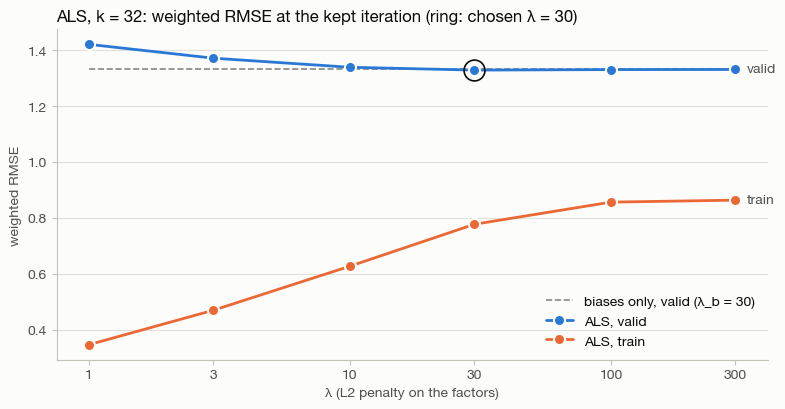

In [16]:
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
VIZ_STYLE = {
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
}
metric_label = SELECT_BY.replace("rmse", "RMSE")

lambdas = als_search.index.to_numpy()
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.hlines(bias_search.loc[best_l2_bias, f"valid {SELECT_BY}"], lambdas[0], lambdas[-1], colors=MUTED,
              linewidths=1.2, linestyles="--", label=f"biases only, valid (λ_b = {best_l2_bias:g})")
    for split, color in (("valid", BLUE), ("train", ORANGE)):
        column = f"{split} {SELECT_BY}"
        ax.plot(lambdas, als_search[column], color=color, lw=2, marker="o", ms=8, mec=SURFACE, mew=1.5,
                solid_capstyle="round", solid_joinstyle="round", label=f"ALS, {split}")
        ax.annotate(split, (lambdas[-1], als_search[column].iat[-1]), xytext=(8, 0), textcoords="offset points",
                    va="center", color=INK_2)
    # The chosen lambda: a ring around its valid point.
    ax.plot(best_l2, als_search.loc[best_l2, f"valid {SELECT_BY}"], marker="o", ms=15, mfc="none", mec=INK, mew=1.2)
    ax.set_xscale("log")
    ax.set_xticks(lambdas, [f"{value:g}" for value in lambdas])
    ax.minorticks_off()
    ax.set(xlabel="λ (L2 penalty on the factors)", ylabel=metric_label,
           title=f"ALS, k = {FACTORS}: {metric_label} at the kept iteration (ring: chosen λ = {best_l2:g})")
    ax.grid(axis="x", visible=False)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

## Test

The chosen models next to the global mean $\mu$. `test, recipe in train` keeps only the test rows whose recipe has a train
rating. On the other rows every model predicts from $\mu$ and $b_u$ alone, so this subset shows what the factors add.

In [17]:
bias_model, als_model = bias_runs[best_l2_bias][0], als_runs[best_l2][0]
test_users, test_recipes, test_values = encoded["test"]
in_train = test_recipes >= 0
eval_rows = {"valid": encoded["valid"], "test": encoded["test"],
             "test, recipe in train": (test_users[in_train], test_recipes[in_train], test_values[in_train])}
models = {
    f"global mean (μ = {als_model['mu']:.2f})": lambda users, recipes: np.full(len(users), als_model["mu"]),
    f"biases only (λ_b={best_l2_bias:g})": lambda users, recipes: predict(bias_model, users, recipes),
    f"ALS k={FACTORS} (λ={best_l2:g}, λ_b={best_l2_bias:g})": lambda users, recipes: predict(als_model, users, recipes),
}
results = pd.DataFrame({(model, split): regression_metrics(values, score(users, recipes))
                        for model, score in models.items()
                        for split, (users, recipes, values) in eval_rows.items()}).T.rename_axis(["model", "split"])
display(results.round(4).unstack("split").swaplevel(axis=1).sort_index(axis=1))
print(f"{(~in_train).mean():.1%} of test rows have a recipe with no train rating.")

split                      test                                \
                            mae     mse    rmse weighted rmse   
model                                                           
ALS k=32 (λ=30, λ_b=30)  1.5673  2.7963  1.6722        1.3448   
biases only (λ_b=30)     1.6058  2.9312  1.7121        1.3444   
global mean (μ = 3.00)   1.7895  3.4334  1.8530        1.4142   

split                   test, recipe in train                                \
                                          mae     mse    rmse weighted rmse   
model                                                                         
ALS k=32 (λ=30, λ_b=30)                1.5615  2.7736  1.6654        1.3359   
biases only (λ_b=30)                   1.6045  2.9254  1.7104        1.3344   
global mean (μ = 3.00)                 1.7999  3.4607  1.8603        1.4142   

split                     valid                                
                            mae     mse    rmse weighted rmse  
model                                                          
ALS k=32 (λ=30, λ_b=30)  1.5487  2.7353  1.6539        1.3287  
biases only (λ_b=30)     1.5879  2.8722  1.6948        1.3308  
global mean (μ = 3.00)   1.7729  3.3897  1.8411        1.4142

10.3% of test rows have a recipe with no train rating.


### How well each rating is predicted

Each test prediction of the chosen ALS model is rounded to the nearest star and scored as a class: **precision** is the share of
the ratings predicted as $r$ that are $r$, **recall** is the share of the true $r$ ratings that are predicted as $r$, and **F1** is
their harmonic mean. The fourth bar in each group, also printed under it, is the share of $r$ among all kept ratings.
A rating that is never predicted gets precision 0.

,precision,recall,f1,share of dataset,test ratings,predicted
rating,,,,,,
1,0.286,0.017,0.031,0.005,241,14
2,0.043,0.193,0.070,0.010,311,1411
3,0.035,0.739,0.066,0.038,610,13047
4,0.096,0.168,0.122,0.184,2432,4273
5,1.000,0.006,0.011,0.763,15237,86


Test accuracy 0.054, macro F1 0.060 (predictions rounded to the nearest star)


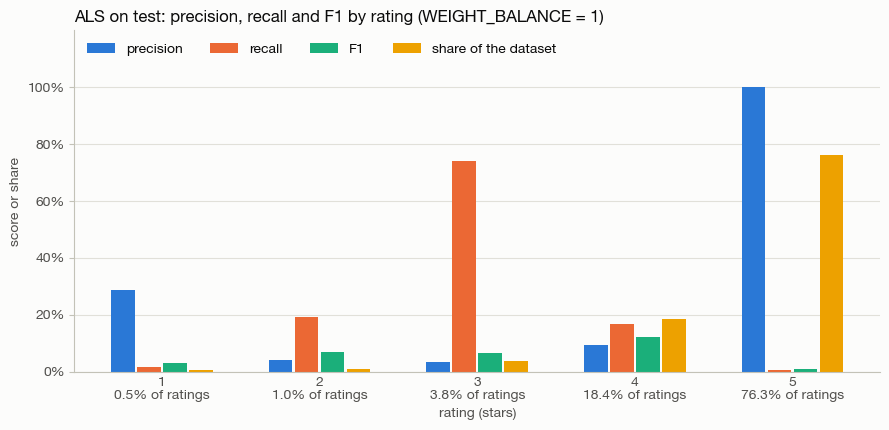

In [18]:
levels = np.arange(RATING_MIN, RATING_MAX + 1)
true_level = test_values.astype(int)
predicted_level = np.rint(predict(als_model, test_users, test_recipes)).astype(int)  # The nearest star.
precision, recall, f1, support = precision_recall_fscore_support(true_level, predicted_level, labels=levels,
                                                                 zero_division=0)
per_rating = pd.DataFrame({
    "precision": precision, "recall": recall, "f1": f1,
    "share of dataset": kept["rating"].value_counts(normalize=True).reindex(levels, fill_value=0).to_numpy(),
    "test ratings": support, "predicted": np.bincount(predicted_level, minlength=RATING_MAX + 1)[levels],
}, index=pd.Index(levels, name="rating"))
display(per_rating.round(3))
print(f"Test accuracy {np.mean(predicted_level == true_level):.3f}, macro F1 {f1.mean():.3f} "
      f"(predictions rounded to the nearest star)")

bars = (("precision", BLUE, "precision"), ("recall", ORANGE, "recall"), ("f1", AQUA, "F1"),
        ("share of dataset", YELLOW, "share of the dataset"))
width, spacing = 0.15, 0.165  # Bar width, and the distance between bar centers (a thin gap between neighbours).
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(9, 4.4))
    for k, (column, color, label) in enumerate(bars):
        ax.bar(levels + (k - (len(bars) - 1) / 2) * spacing, per_rating[column], width=width, color=color, label=label)
    ax.set_xticks(levels, [f"{r}\n{share:.1%} of ratings" for r, share in zip(levels, per_rating["share of dataset"])])
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set(ylim=(0, 1.2), xlabel="rating (stars)", ylabel="score or share",
           title=f"ALS on test: precision, recall and F1 by rating (WEIGHT_BALANCE = {WEIGHT_BALANCE:g})")
    ax.tick_params(axis="x", length=0)
    ax.grid(axis="x", visible=False)
    ax.legend(frameon=False, ncols=4, loc="upper left")
    fig.tight_layout()
    plt.show()

## Save the model

`model_artifacts/mf_als/` holds:

- `als_model.npz`: `mu`; `user_bias` and `user_factors`, one row per entry of `user_ids`; `item_bias` and `item_factors`, one row per entry of `recipe_ids`.
- `l2_search.csv` (both searches), `metrics.csv` (the test table), `per_rating.csv` (precision, recall, and F1 by rating), and
  `config.json` (data filters, split, class weights, and hyperparameters).

To score user $u$ on recipe $i$, add $\mu$, $b_u$, $c_i$, and $p_u^\top q_i$, leaving out the terms of a user or recipe that is not
in the vocabulary, then clip to [1, 5].

In [19]:
ALS_DIR.mkdir(parents=True, exist_ok=True)
np.savez(ALS_DIR / "als_model.npz", user_ids=user_ids, recipe_ids=recipe_ids, mu=als_model["mu"],
         user_bias=als_model["user_bias"], user_factors=als_model["user_factors"],
         item_bias=als_model["item_bias"], item_factors=als_model["item_factors"])
pd.concat({"biases only": bias_search.rename_axis("l2"), f"ALS k={FACTORS}": als_search.rename_axis("l2")},
          names=["model"]).to_csv(ALS_DIR / "l2_search.csv")
results.to_csv(ALS_DIR / "metrics.csv")
per_rating.to_csv(ALS_DIR / "per_rating.csv")
(ALS_DIR / "config.json").write_text(json.dumps({
    "task": "explicit rating regression: biased matrix factorization fitted by ALS",
    "data": str(DATA_PATH.relative_to(NOTEBOOK_DIR)), "target": "rating", "rating_range": [RATING_MIN, RATING_MAX],
    "min_user_ratings": MIN_USER_RATINGS,
    "split": "per user by date: latest rating -> test, the one before -> valid, the rest -> train",
    "users": len(user_ids), "recipes": len(recipe_ids), "train_ratings": int(R.nnz),
    "weight_balance": WEIGHT_BALANCE,
    "rating_weights": {str(r): float(rating_weight[r]) for r in range(RATING_MIN, RATING_MAX + 1)},
    "select_by": SELECT_BY, "factors": FACTORS, "l2": best_l2, "l2_bias": best_l2_bias,
    "l2_grid": L2_GRID, "l2_bias_grid": L2_BIAS_GRID, "iterations": int(als_model["iterations"]),
    "init_std": INIT_STD, "random_state": RANDOM_STATE,
}, indent=2))
print(f"Saved to {ALS_DIR}: {sorted(p.name for p in ALS_DIR.iterdir())}")

Saved to /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/mf_als: ['als_model.npz', 'config.json', 'l2_search.csv', 'metrics.csv', 'per_rating.csv']
